# 2D Stereocilia Analysis — Complete Pipeline

**Dataset:** VASCilia P21 — flat 2D green-channel TIFFs + PNG bundle masks  
**Image shape:** (1799 × 1799) float32, intensity range [0, 255]  
**Pixel size:** 0.043 µm × 0.043 µm  

## Pipeline Stages
| Stage | Techniques |
|-------|------------|
| **1. Data Loading** | VASCilia 2D loader, folder parsing |
| **2. Preprocessing** | Normalization, transforms, CLAHE, sharpening, rolling-ball, FFT, IQA |
| **3. Denoising** | Gaussian, Median, Bilateral, NLM, TV Chambolle, DCT averaging |
| **4. Segmentation** | Multi-Otsu, Watershed, Cellpose cyto3 CPU |
| **5. Feature Extraction** | Morphology, Intensity, GLCM, LBP, Gabor, HOG, Keypoints, Edges, PCP |
| **6. Row Classification** | PCA + K-Means → IHC / OHC1 / OHC2 / OHC3 |
| **7. Statistical Analysis** | Distributions, Mann-Whitney, Cohen's d, UMAP |

**Sources:** `python_for_microscopists` (files 020–124, 200a, 061), `3D-Organoid-Analysis`, `src/` classes

---
## Section 0 — Configuration & Imports

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns

# Image processing — core
import tifffile as tiff
from skimage import io, color, exposure, filters, feature, restoration, measure, morphology, transform, segmentation
from scipy import ndimage, stats, fftpack
from scipy.stats import mannwhitneyu, shapiro, levene

# Suppress minor warnings for clean output
warnings.filterwarnings('ignore')

# ── Project root setup ──────────────────────────────────────────────────────
PROJECT_ROOT = Path(r"E:\3D-Cochlear-Quantifier\Dataset\VASCilia_3D_DataSet\Repo building\vascilia_pipeline_complete\vascilia-haircell-3d-analysis")
DATA_ROOT    = Path(r"E:\3D-Cochlear-Quantifier\Dataset\VASCilia_3D_DataSet\P21")

for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / 'src' / 'data_loader.py').exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Physics constants ────────────────────────────────────────────────────────
PIXEL_SIZE_UM = (0.043, 0.043)   # (dy, dx) in microns

print(f'Project root : {PROJECT_ROOT}')
print(f'Data root    : {DATA_ROOT}')
print(f'Pixel size   : {PIXEL_SIZE_UM} µm')
print('✓ Imports OK')

Project root : E:\3D-Cochlear-Quantifier\Dataset\VASCilia_3D_DataSet\Repo building\vascilia_pipeline_complete\vascilia-haircell-3d-analysis
Data root    : E:\3D-Cochlear-Quantifier\Dataset\VASCilia_3D_DataSet\P21
Pixel size   : (0.043, 0.043) µm
✓ Imports OK


---
## Section 1 — Data Loading

The VASCilia folder layout:
```
<stack_id>/
    raw_images/            ← flat 2-D TIFF (green channel, F-actin)
    new_assignment_obj/    ← integer PNG label mask (one label per bundle)
```
Pixel size is **0.043 µm/px** (Airyscan). Images are independent 2-D planes — **no Z stack**.

In [2]:
from src.data_loader import load_stack_pair, load_image_mask_pairs

# ── Pick demo subject (first row of metadata CSV) ────────────────────────────
metadata_path = PROJECT_ROOT / 'results' / 'master_metadata_P21.csv'
md = pd.read_csv(metadata_path)
demo_id = md.iloc[0]['stack_id']
print(f'Loading: {demo_id}')

image_raw, mask, folder = load_stack_pair(DATA_ROOT, demo_id, verbose=True)

print(f'\nImage  : shape={image_raw.shape}  dtype={image_raw.dtype}')
print(f'Mask   : shape={mask.shape}  n_bundles={len(np.unique(mask)) - 1}')
print(f'Intensity range : [{image_raw.min():.1f}, {image_raw.max():.1f}]')

Loading: Litter18Mouse2APEX-Eps8KONegativeControl_Airy
  loaded 2D pair 0 from Litter18Mouse2APEX-Eps8KONegativeControl_Airy
      image: (1799, 1799) dtype=float32
      mask : (1799, 1799) n_labels=17

Image  : shape=(1799, 1799)  dtype=float32
Mask   : shape=(1799, 1799)  n_bundles=17
Intensity range : [0.0, 255.0]


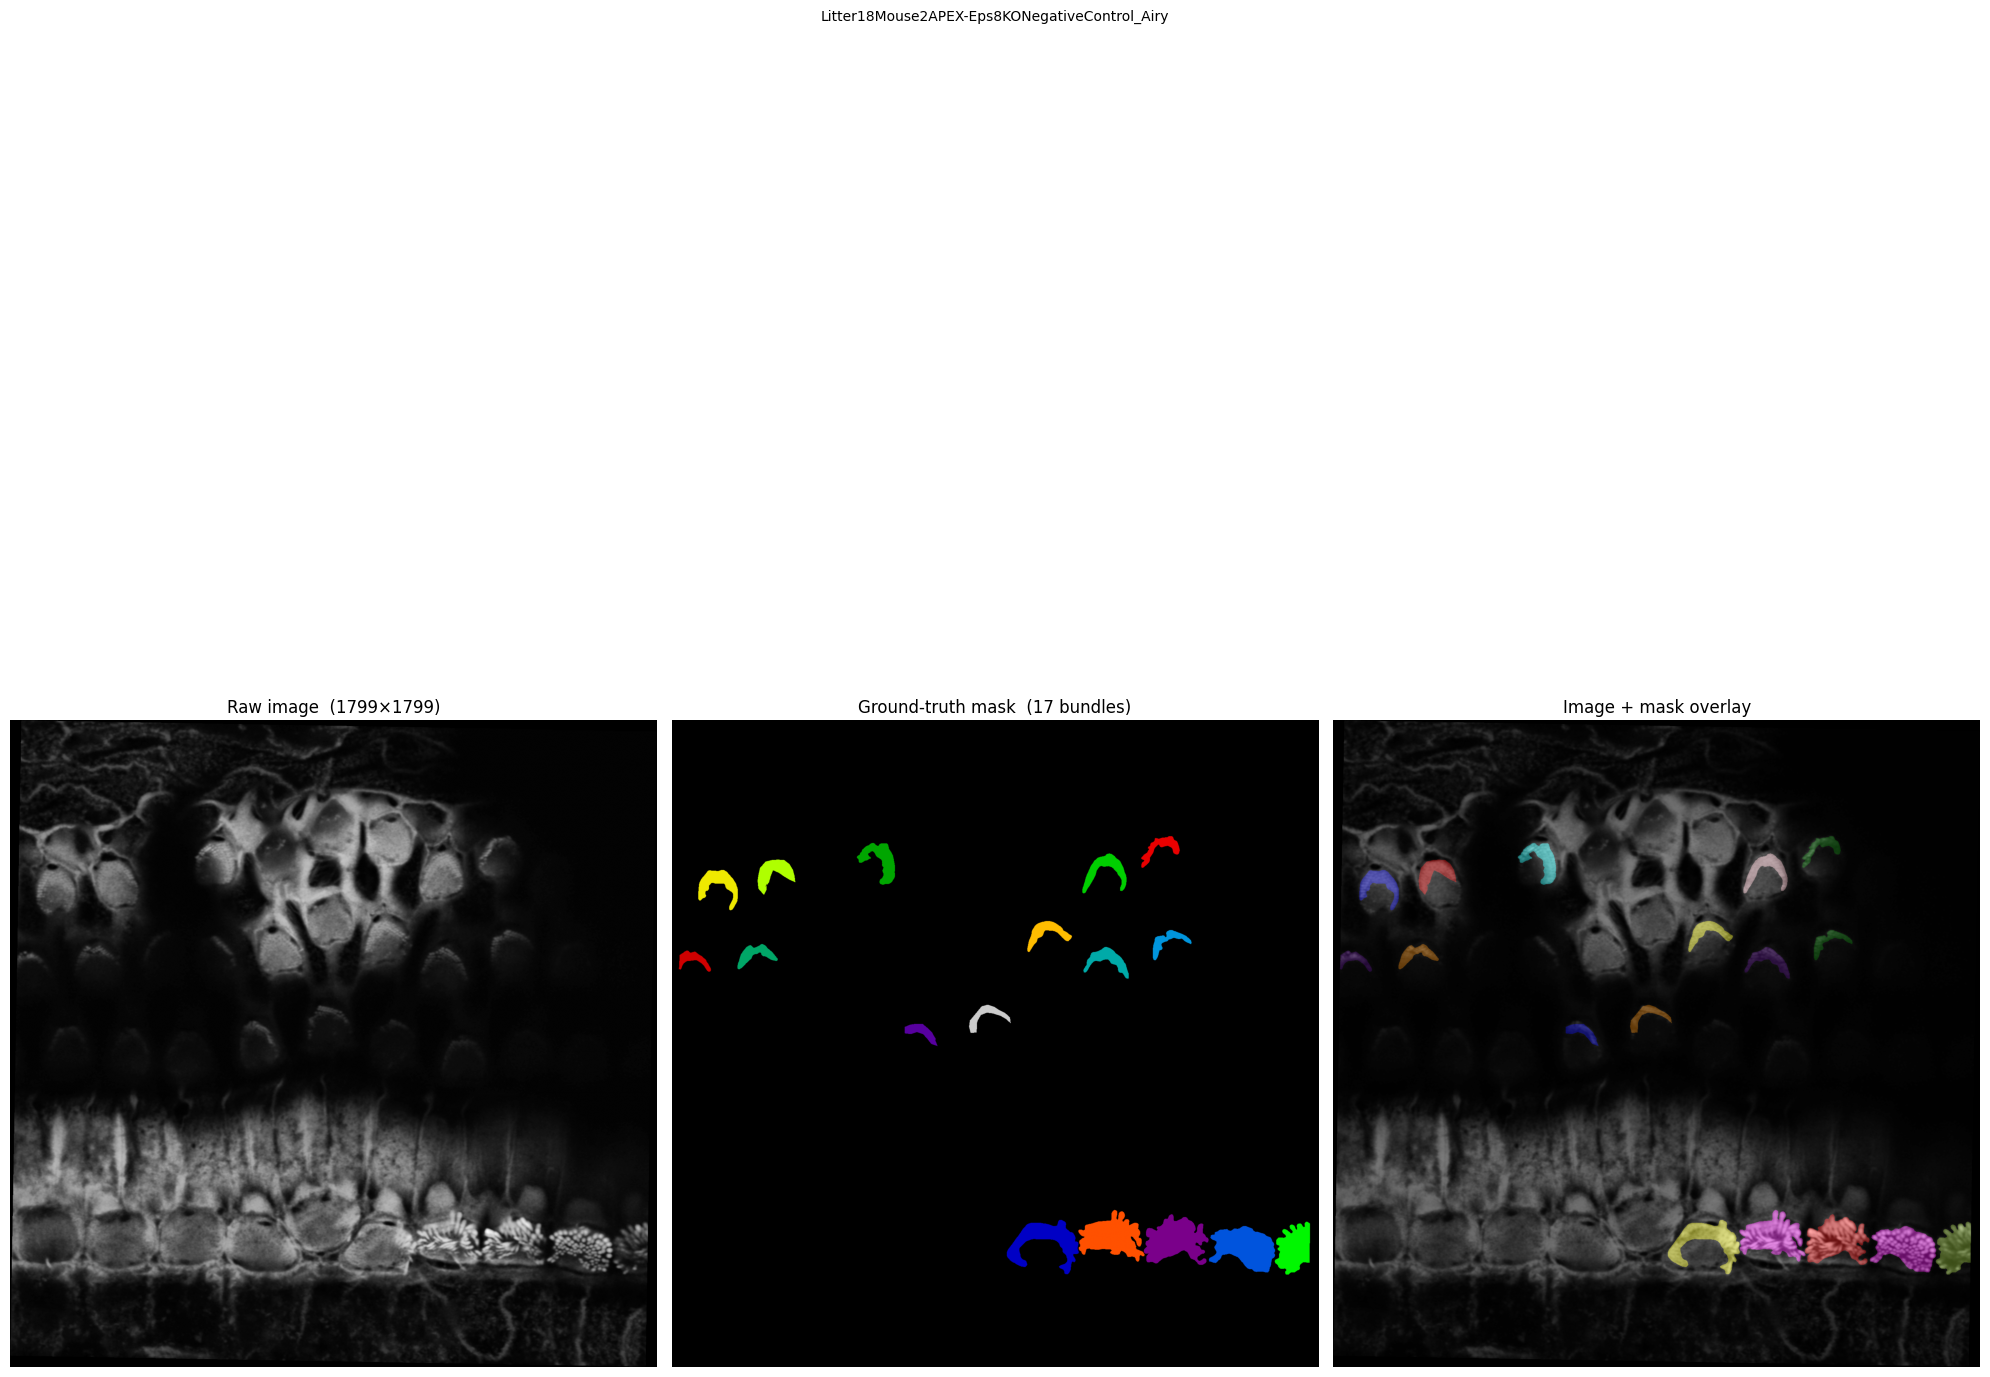

In [11]:
from skimage.color import label2rgb

fig, axes = plt.subplots(1, 3, figsize=(20, 20))

axes[0].imshow(image_raw, cmap='gray')
axes[0].set_title(f'Raw image  ({image_raw.shape[0]}×{image_raw.shape[1]})', fontsize=12)
axes[0].axis('off')

axes[1].imshow(mask, cmap='nipy_spectral')
axes[1].set_title(f'Ground-truth mask  ({len(np.unique(mask))-1} bundles)', fontsize=12)
axes[1].axis('off')

overlay = label2rgb(mask, image=image_raw / 255.0, alpha=0.35, bg_label=0)
axes[2].imshow(overlay)
axes[2].set_title('Image + mask overlay', fontsize=12)
axes[2].axis('off')

plt.suptitle(demo_id, fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 2 — Preprocessing Layer

Based on `python_for_microscopists` files **020, 027, 102, 105, 106, 113, 117, 123, 124**  
and `src/preprocessing_classes.py`.

### 2A. Intensity Normalization — Percentile Clipping

$$I_{norm} = \frac{\text{clip}(I, p_2, p_{98}) - p_2}{p_{98} - p_2} \in [0, 1]$$

Removes extreme outlier pixels before any downstream processing.

In [1]:
from src.preprocessing_classes import IntensityNormalizer

normalizer = IntensityNormalizer(p_lo=2.0, p_hi=98.0)
img_norm = normalizer.apply(image_raw)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(image_raw, cmap='gray')
axes[0].set_title(f'Raw  range=[{image_raw.min():.0f}, {image_raw.max():.0f}]')
axes[0].axis('off')

axes[1].imshow(img_norm, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Normalized  range=[{img_norm.min():.2f}, {img_norm.max():.2f}]')
axes[1].axis('off')

axes[2].hist(image_raw.ravel(), bins=128, color='steelblue', alpha=0.7)
axes[2].set_title('Raw histogram')
axes[2].set_xlabel('Intensity')

axes[3].hist(img_norm.ravel(), bins=128, color='coral', alpha=0.7)
axes[3].set_title('Normalized histogram')
axes[3].set_xlabel('Intensity [0,1]')

plt.tight_layout()
plt.show()
print(f'p2={np.percentile(image_raw, 2):.1f}  p98={np.percentile(image_raw, 98):.1f}')

ModuleNotFoundError: No module named 'src'

### 2B. Image Transforms — Rescale / Resize / Downscale

From `python_for_microscopists` file **020**.  
Useful for multi-scale analysis or reducing computation on the 1799×1799 image.

| Operation | API | Effect |
|-----------|-----|--------|
| `rescale(img, 0.5)` | skimage.transform | Scale by factor |
| `resize(img, (512, 512))` | skimage.transform | Fixed output shape |
| `downscale_local_mean(img, (4,4))` | skimage.transform | Block-average ↓ |

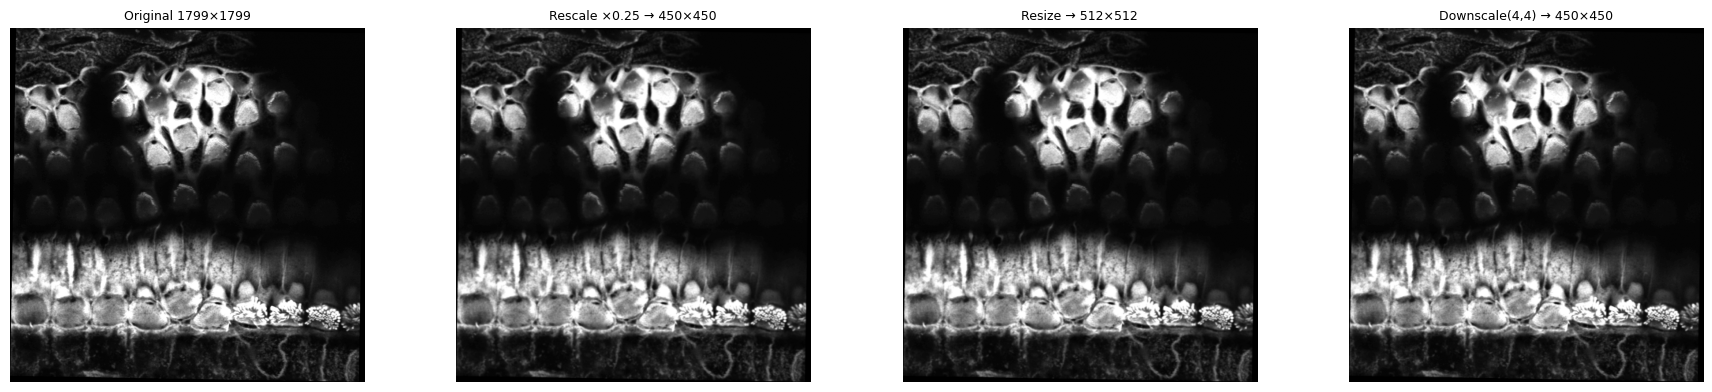

Working image for demos: (450, 450)


In [5]:
from skimage.transform import rescale, resize, downscale_local_mean

img_rescaled   = rescale(img_norm, 0.25, anti_aliasing=True)          # 0.25× → ~450×450
img_resized    = resize(img_norm, (512, 512), anti_aliasing=True)      # fixed 512×512
img_downscaled = downscale_local_mean(img_norm, (4, 4))               # 4× block average

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, im, t in zip(axes,
    [img_norm, img_rescaled, img_resized, img_downscaled],
    ['Original 1799×1799', f'Rescale ×0.25 → {img_rescaled.shape[0]}×{img_rescaled.shape[1]}',
     'Resize → 512×512', f'Downscale(4,4) → {img_downscaled.shape[0]}×{img_downscaled.shape[1]}']):
    ax.imshow(im, cmap='gray')
    ax.set_title(t, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Work with quarter-scale for speed in demo cells below
img_small = img_rescaled.copy()
print(f'Working image for demos: {img_small.shape}')

### 2C. Contrast Enhancement — Global HE and CLAHE

From files **027, 113**.  

**CLAHE** (Contrast-Limited Adaptive Histogram Equalization):  
Divides the image into tiles and equalises each tile independently, then  
bilinear-interpolates boundaries. Clip limit prevents over-amplification of noise.

$$\text{CDF}_{tile}(v) \xrightarrow{\text{clip + redistribute}} \text{CDF}_{equalized}(v)$$

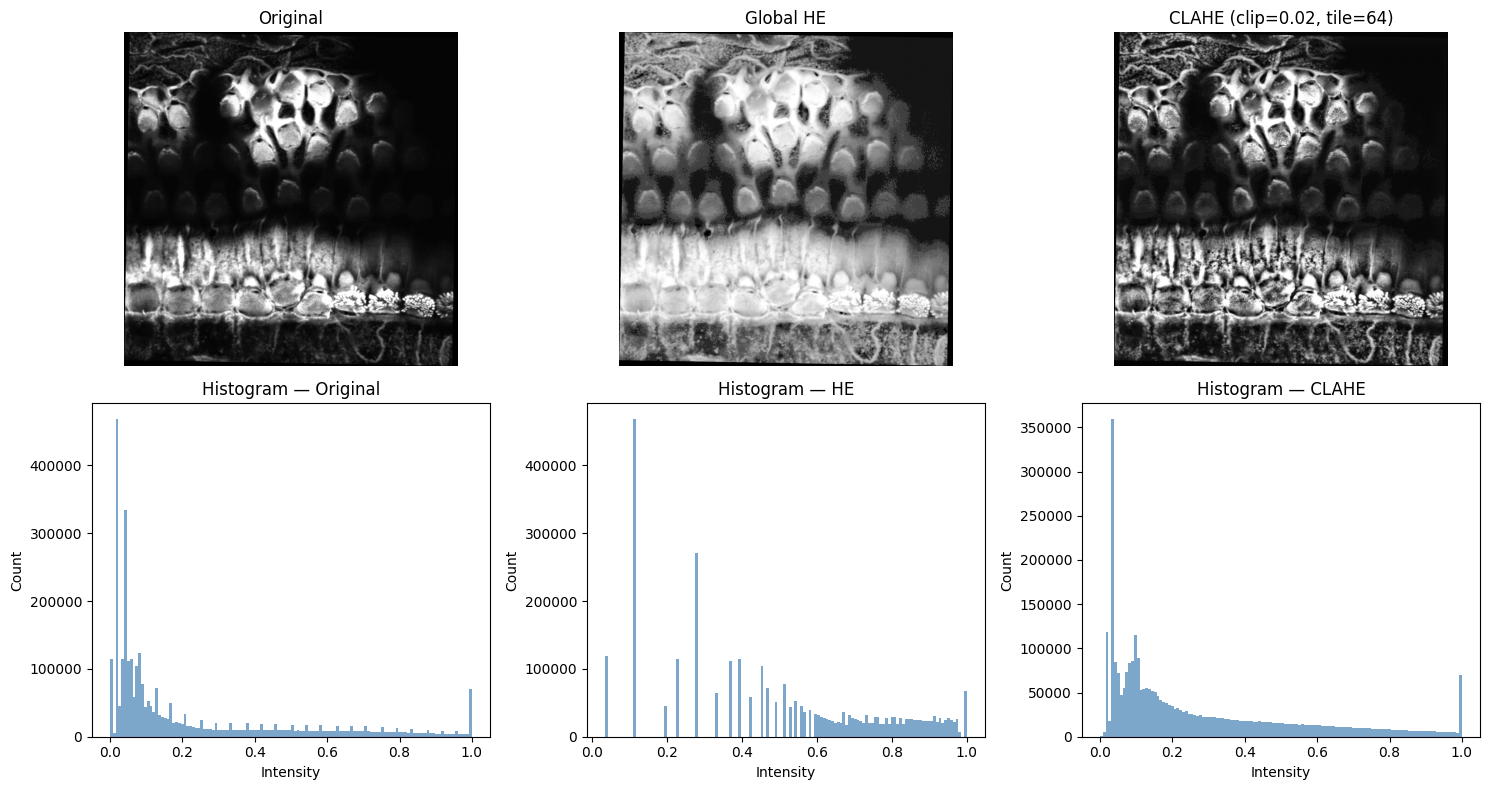

In [6]:
from skimage.exposure import equalize_hist, equalize_adapthist

img_he    = equalize_hist(img_norm)
img_clahe = equalize_adapthist(img_norm, clip_limit=0.02, kernel_size=64)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, im, t in zip(axes[0],
    [img_norm, img_he, img_clahe],
    ['Original', 'Global HE', 'CLAHE (clip=0.02, tile=64)']):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')

for ax, im, t in zip(axes[1],
    [img_norm, img_he, img_clahe],
    ['Histogram — Original', 'Histogram — HE', 'Histogram — CLAHE']):
    ax.hist(im.ravel(), bins=128, color='steelblue', alpha=0.7)
    ax.set_title(t)
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### 2D. Sharpening — Unsharp Mask & Wiener Deconvolution

From files **020, 102**.  

**Unsharp mask:**  
$$I_{sharp} = I + \alpha \cdot (I - G_\sigma * I)$$

**Wiener deconvolution:** Assumes known PSF $h$ and noise:  
$$\hat{I} = \mathcal{F}^{-1}\!\left[\frac{H^*(\omega)}{|H(\omega)|^2 + \lambda}\, \mathcal{F}[I]\right]$$

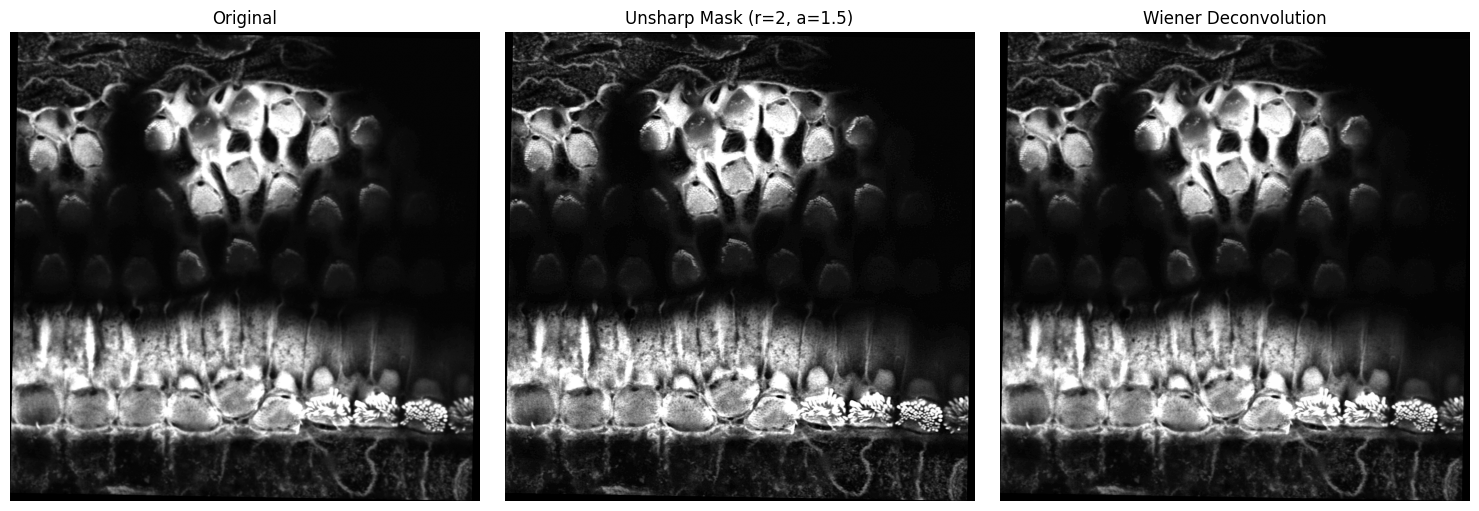

In [7]:
import scipy.stats as st
from skimage.filters import unsharp_mask
from skimage.restoration import unsupervised_wiener

# Unsharp mask — radius and amount
img_unsharp = unsharp_mask(img_norm, radius=2.0, amount=1.5)

# Gaussian PSF for Wiener deconvolution
def gaussian_psf(klen=11, sigma=1.5):
    lim = klen // 2 + (klen % 2) / 2
    x = np.linspace(-lim, lim, klen + 1)
    k1d = np.diff(st.norm.cdf(x))
    k2d = np.outer(k1d, k1d)
    return k2d / k2d.sum()

psf = gaussian_psf(klen=9, sigma=1.5)
img_wiener, _ = unsupervised_wiener(img_norm, psf)
img_wiener = np.clip(img_wiener, 0, 1).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, im, t in zip(axes,
    [img_norm, img_unsharp, img_wiener],
    ['Original', 'Unsharp Mask (r=2, a=1.5)', 'Wiener Deconvolution']):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.show()

### 2E. Background Subtraction — Rolling Ball

From file **117**.  
Estimates a slowly-varying background by rolling a sphere of given radius  
under the image surface. Subtracting it corrects uneven illumination.

$$I_{corrected}(x,y) = I(x,y) - B_{rolling}(x,y)$$

cv2_rolling_ball not installed — skipping rolling ball.
Install: pip install cv2-rolling-ball


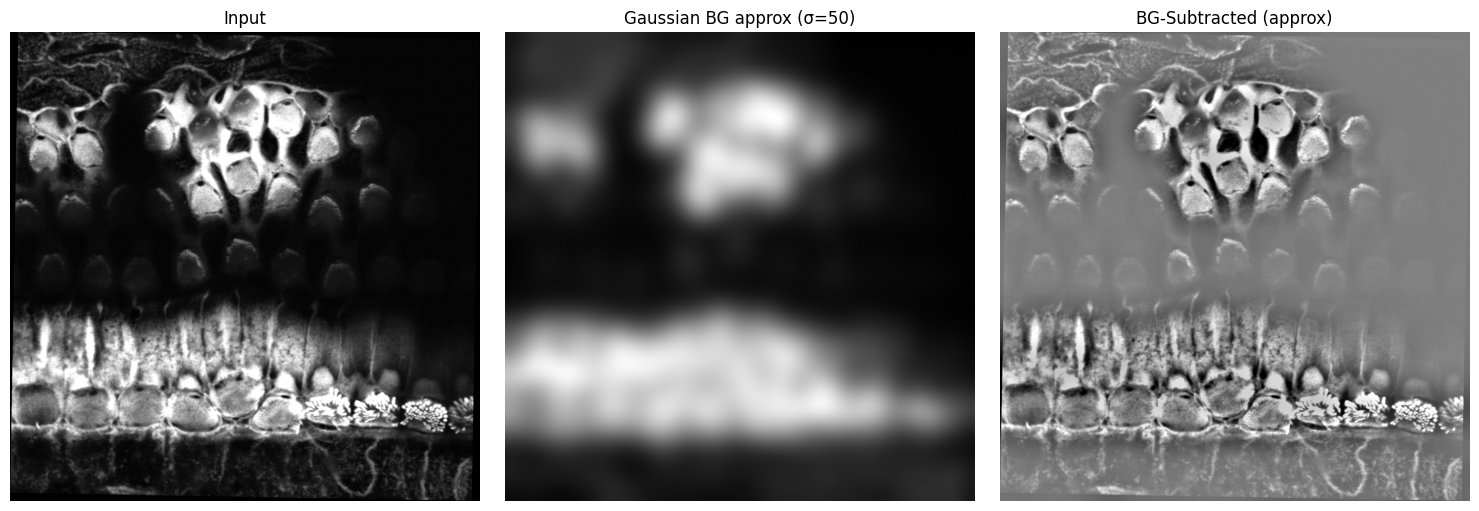

In [8]:
try:
    from cv2_rolling_ball import subtract_background_rolling_ball

    img_uint8 = (img_norm * 255).astype(np.uint8)
    img_rb, background = subtract_background_rolling_ball(
        img_uint8, radius=100, light_background=False,
        use_paraboloid=False, do_presmooth=True
    )
    img_rb = img_rb.astype(np.float32) / 255.0
    background_f = background.astype(np.float32) / 255.0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, im, t in zip(axes,
        [img_norm, background_f, img_rb],
        ['Input', 'Estimated Background (r=100)', 'Background-Subtracted']):
        ax.imshow(im, cmap='gray')
        ax.set_title(t)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    print('Rolling ball correction applied.')
except ImportError:
    print('cv2_rolling_ball not installed — skipping rolling ball.')
    print('Install: pip install cv2-rolling-ball')
    # Approximate alternative: subtract Gaussian-blurred background
    bg_approx = ndimage.gaussian_filter(img_norm, sigma=50)
    img_rb = np.clip(img_norm - bg_approx + 0.5, 0, 1).astype(np.float32)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, im, t in zip(axes,
        [img_norm, bg_approx, img_rb],
        ['Input', 'Gaussian BG approx (σ=50)', 'BG-Subtracted (approx)']):
        ax.imshow(im, cmap='gray')
        ax.set_title(t)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### 2F. Frequency-Domain Analysis — FFT + Low/High-Pass Filters

From files **105, 106**.  

The 2-D DFT transforms the image to frequency space. The origin (after `fftshift`)  
represents **DC / low frequencies**; edges represent **high frequencies / fine detail**.

| Filter | Mask | Effect |
|--------|------|--------|
| Low-pass | Pass only centre disk | Blur / smooth |
| High-pass | Suppress centre disk | Edge enhancement |
| Band-pass | Annular mask | Select frequency range |

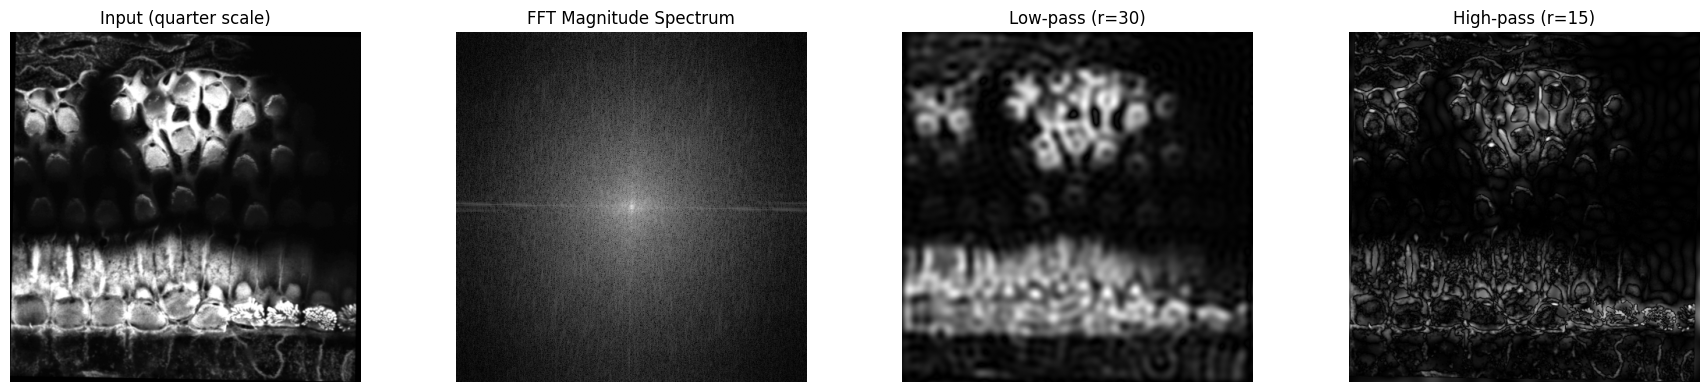

In [9]:
def circular_mask(shape, radius, invert=False):
    h, w = shape
    cy, cx = h // 2, w // 2
    Y, X = np.ogrid[:h, :w]
    dist = np.sqrt((Y - cy)**2 + (X - cx)**2)
    mask = (dist <= radius).astype(np.float32)
    return (1 - mask) if invert else mask

def fft_filter(img, radius, highpass=False):
    F = np.fft.fft2(img)
    Fs = np.fft.fftshift(F)
    mask = circular_mask(img.shape, radius, invert=highpass)
    filtered = np.fft.ifftshift(Fs * mask)
    result = np.abs(np.fft.ifft2(filtered)).astype(np.float32)
    lo, hi = result.min(), result.max()
    return (result - lo) / (hi - lo + 1e-8)

# Magnitude spectrum
F = np.fft.fftshift(np.fft.fft2(img_small))
mag = np.log1p(np.abs(F)).astype(np.float32)

img_lpf = fft_filter(img_small, radius=30, highpass=False)   # low-pass
img_hpf = fft_filter(img_small, radius=15, highpass=True)    # high-pass

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, im, t in zip(axes,
    [img_small, mag, img_lpf, img_hpf],
    ['Input (quarter scale)', 'FFT Magnitude Spectrum',
     'Low-pass (r=30)', 'High-pass (r=15)']):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.show()

### 2G. Image Quality Assessment — PSNR, SSIM, Sharpness

From files **114, 123, 124**.  

| Metric | Formula / Library | Interpretation |
|--------|-------------------|----------------|
| **PSNR** | $10 \log_{10}(\text{MAX}^2 / \text{MSE})$ | Higher = less noise |
| **SSIM** | Perceptual similarity | 1 = identical |
| **Laplacian variance** | $\text{Var}(\nabla^2 I)$ | Higher = sharper |

In [10]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

def laplacian_sharpness(img):
    lap = ndimage.laplace(img.astype(np.float64))
    return float(lap.var())

# Compare normalization variants against raw/255
ref = image_raw / 255.0
variants = {
    'Normalized (p2/p98)': img_norm,
    'HE': img_he,
    'CLAHE': img_clahe,
    'Unsharp Mask': img_unsharp,
    'Wiener': img_wiener,
}

rows = []
for name, img in variants.items():
    psnr = peak_signal_noise_ratio(ref, img, data_range=1.0)
    ssim = structural_similarity(ref, img, data_range=1.0)
    sharp = laplacian_sharpness(img)
    rows.append({'Variant': name, 'PSNR (dB)': round(psnr, 2),
                 'SSIM': round(ssim, 4), 'Sharpness (Lap. Var.)': round(sharp, 6)})

df_iqa = pd.DataFrame(rows)
print('Image Quality Metrics (reference = raw/255):\n')
print(df_iqa.to_string(index=False))

KeyboardInterrupt: 

### 2H. Full Preprocessing Pipeline

Runs the `src/preprocessing_classes.py` orchestrator:  
**IntensityNormalizer → (optional CLAHE) → (optional Denoiser)**

In [ ]:
from src.preprocessing_classes import PreprocessingPipeline

pipe = PreprocessingPipeline(
    use_clahe=True,
    denoise_method='gaussian',
    p_lo=2.0, p_hi=98.0,
    sigma_xy=1.0
)
img_pp, mask_pp, pipe_meta = pipe.run(image_raw, mask)

print('Pipeline metadata:')
for k, v in pipe_meta.items():
    print(f'  {k}: {v}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_raw, cmap='gray')
axes[0].set_title('Raw input')
axes[0].axis('off')
axes[1].imshow(img_pp, cmap='gray')
axes[1].set_title('After pipeline (CLAHE + Gaussian σ=1)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

---
## Section 3 — Denoising Pipeline

Based on files **022, 096, 097, 098, 099, 100, 112**.  
All methods are **CPU-only** and evaluated with SSIM vs the normalized input.

| # | Method | Best for | Key parameter |
|---|--------|----------|---------------|
| 1 | Gaussian | Gaussian noise | σ (blur radius) |
| 2 | Median | Salt & pepper | kernel size |
| 3 | Bilateral | Edge preservation | σ_color, σ_spatial |
| 4 | NLM | Repetitive textures | h (patch strength) |
| 5 | TV Chambolle | Piecewise smooth | weight λ |
| 6 | DCT averaging | Multiple acquisitions | N images |

### Formulas

**Gaussian:** $I'(p) = \sum_q G_\sigma(p-q)\,I(q)$

**Bilateral:** $I'(p) = \frac{\sum_q G_{\sigma_s}(\|p-q\|)\,G_{\sigma_r}(|I(p)-I(q)|)\,I(q)}{Z}$

**NLM:** $I'(p) = \sum_q w(p,q)\,I(q)$ where $w \propto \exp(-\|P_p - P_q\|^2/h^2)$

**TV Chambolle:** $\min_u \frac{1}{2}\|u - I\|^2 + \lambda \|\nabla u\|_1$

In [ ]:
from skimage.restoration import denoise_nl_means, denoise_bilateral, denoise_tv_chambolle, estimate_sigma

# Use the preprocessed full-resolution image
img_in = img_pp.copy()   # float32 in [0,1]

sigma_est = estimate_sigma(img_in)
print(f'Estimated noise σ = {sigma_est:.4f}')

denoised = {
    'Input': img_in,
    'Gaussian σ=0.5': ndimage.gaussian_filter(img_in, sigma=0.5),
    'Gaussian σ=1.5': ndimage.gaussian_filter(img_in, sigma=1.5),
    'Median (3×3)': ndimage.median_filter(img_in, size=3),
    'Bilateral': denoise_bilateral(img_in, sigma_color=0.05, sigma_spatial=2),
    'NLM fast': denoise_nl_means(img_in, h=sigma_est * 1.15,
                                  fast_mode=True, patch_size=5, patch_distance=3),
    'TV Chambolle': denoise_tv_chambolle(img_in, weight=0.05),
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, (t, im) in zip(axes.ravel(), denoised.items()):
    ax.imshow(im, cmap='gray')
    ax.set_title(t, fontsize=9)
    ax.axis('off')
# Hide extra subplot
axes.ravel()[-1].set_visible(False)
plt.suptitle('Denoising Comparison', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Quantitative comparison — SSIM and sharpness
ref_dn = img_in
rows_dn = []
for name, img in denoised.items():
    if name == 'Input':
        continue
    ssim_val = structural_similarity(ref_dn, img.astype(ref_dn.dtype), data_range=1.0)
    sharp_val = laplacian_sharpness(img)
    rows_dn.append({'Method': name, 'SSIM vs Input': round(ssim_val, 4),
                    'Sharpness': round(sharp_val, 6)})

df_denoise = pd.DataFrame(rows_dn).sort_values('SSIM vs Input', ascending=False)
print('Denoising quality metrics (higher SSIM = more faithful, higher sharpness = more detail):')
print(df_denoise.to_string(index=False))

# Pick best for downstream use
img_denoised = denoised['NLM fast'].copy()
print(f'\n→ Using NLM fast for downstream processing')

### 3F. DCT Averaging (file 112)

Averaging multiple acquisitions in **DCT space** suppresses incoherent noise  
more effectively than simple spatial averaging, because coherent signal  
reinforces in frequency but random noise cancels.

$$\bar{I}_{DCT} = \text{IDCT}\left(\frac{1}{N}\sum_{i=1}^N \text{DCT}(I_i + \epsilon_i)\right)$$

We simulate $N=5$ acquisitions by adding synthetic Gaussian noise.

In [ ]:
from scipy.fftpack import dct, idct

def dct2(x):
    return dct(dct(x.T, norm='ortho').T, norm='ortho')

def idct2(x):
    return idct(idct(x.T, norm='ortho').T, norm='ortho')

# Simulate N acquisitions with σ=0.03 Gaussian noise
N_acq = 5
rng = np.random.default_rng(42)
noise_sigma = 0.03

avg_spatial = np.zeros_like(img_small, dtype=np.float64)
avg_dct = np.zeros_like(img_small, dtype=np.float64)

for _ in range(N_acq):
    noisy = img_small + rng.normal(0, noise_sigma, img_small.shape)
    avg_spatial += noisy / N_acq
    avg_dct += dct2(noisy) / N_acq

img_dct_avg = idct2(avg_dct).astype(np.float32)
img_dct_avg = np.clip(img_dct_avg, 0, 1)

noisy_example = (img_small + rng.normal(0, noise_sigma, img_small.shape)).clip(0, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, im, t in zip(axes,
    [img_small, noisy_example.astype(np.float32), avg_spatial.astype(np.float32), img_dct_avg],
    ['Clean (quarter-scale)', 'One noisy acquisition',
     f'Spatial avg (N={N_acq})', f'DCT avg (N={N_acq})']):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')
plt.suptitle('DCT Averaging vs Spatial Averaging', fontsize=11)
plt.tight_layout()
plt.show()

ssim_spatial = structural_similarity(img_small, avg_spatial.astype(np.float32), data_range=1.0)
ssim_dct = structural_similarity(img_small, img_dct_avg, data_range=1.0)
print(f'SSIM — Spatial avg: {ssim_spatial:.4f}  |  DCT avg: {ssim_dct:.4f}')

---
## Section 4 — Segmentation

Three CPU-friendly algorithms:

1. **Multi-Otsu** (file 115) — automatic multi-class thresholding  
2. **Watershed** (files 033–035) — distance-transform seeded  
3. **Cellpose `cyto3`** (file 305) — flow-field deep model, `gpu=False`  

All compared against the ground-truth VASCilia mask.

### 4A. Multi-Otsu Thresholding (file 115)

Finds $N-1$ thresholds that minimise intra-class variance for $N$ classes:
$$t^* = \arg\min_{t} \sum_{k=1}^{N} w_k \sigma_k^2(t)$$

In [ ]:
from skimage.filters import threshold_multiotsu

thresholds = threshold_multiotsu(img_denoised, classes=3)
regions = np.digitize(img_denoised, bins=thresholds)

# Use the foreground class (highest intensity = bundles)
bundle_mask_otsu = (regions == regions.max()).astype(np.uint8)
labeled_otsu = measure.label(bundle_mask_otsu, connectivity=2)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img_denoised, cmap='gray')
axes[0].set_title('Denoised input')
axes[0].axis('off')

axes[1].hist(img_denoised.ravel(), bins=256, color='steelblue', alpha=0.7)
for t in thresholds:
    axes[1].axvline(t, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Histogram + thresholds {[f"{t:.2f}" for t in thresholds]}')

axes[2].imshow(regions, cmap='viridis')
axes[2].set_title('3-class Multi-Otsu')
axes[2].axis('off')

axes[3].imshow(label2rgb(labeled_otsu, bg_label=0), )
axes[3].set_title(f'Labeled bundles: {labeled_otsu.max()}')
axes[3].axis('off')

plt.tight_layout()
plt.show()
print(f'Multi-Otsu thresholds: {thresholds}  |  Detected components: {labeled_otsu.max()}')

### 4B. Watershed Segmentation (files 033–035)

1. Otsu threshold → binary foreground  
2. Distance transform → local maxima as seed markers  
3. Watershed fills from seeds toward boundaries

$$D(p) = \min_{q \in \text{background}} \|p - q\|$$

In [ ]:
from skimage.filters import threshold_otsu
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.morphology import remove_small_objects

thresh = threshold_otsu(img_denoised)
binary = img_denoised > thresh
binary = morphology.binary_opening(binary, morphology.disk(3))
binary = remove_small_objects(binary, min_size=200)

dist = ndimage.distance_transform_edt(binary)

# Find seed points as local maxima of distance map
coords = peak_local_max(dist, min_distance=20, labels=binary)
seed_mask = np.zeros(dist.shape, dtype=bool)
seed_mask[tuple(coords.T)] = True
markers = measure.label(seed_mask)

labeled_ws = watershed(-dist, markers, mask=binary)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, im, t, cm in zip(axes,
    [binary, dist, markers, labeled_ws],
    ['Binary (Otsu + opening)', 'Distance transform',
     f'Seeds ({markers.max()} markers)', f'Watershed ({labeled_ws.max()} regions)'],
    ['gray', 'viridis', 'nipy_spectral', 'nipy_spectral']):
    ax.imshow(im, cmap=cm)
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Watershed regions: {labeled_ws.max()}  |  GT bundles: {len(np.unique(mask))-1}')

### 4C. Cellpose — cyto3 CPU Model (file 305)

Cellpose simulates a gradient vector field converging to cell centres.  
The `cyto3` model is the latest pre-trained cytoplasm model.

**Parameters (from SOP):**
- `diameter=50` px (matches stereocilia bundle size at 0.043 µm/px)
- `flow_threshold=0.6` — higher = stronger separation
- `cellprob_threshold=0` — detection sensitivity
- `gpu=False` — CPU inference

In [ ]:
CELL_DIAMETER        = 50
CELL_FLOW_THRESHOLD  = 0.6
CELL_CELLPROB_THRESHOLD = 0

try:
    from cellpose import models

    cell_model = models.CellposeModel(gpu=False, model_type='cyto3')
    print(f'✓ Cellpose model loaded: cyto3 (CPU)')

    # Cellpose expects uint8 or float [0,1]; use denoised float
    masks_cp, flows_cp, styles_cp = cell_model.eval(
        img_denoised,
        diameter=CELL_DIAMETER,
        flow_threshold=CELL_FLOW_THRESHOLD,
        cellprob_threshold=CELL_CELLPROB_THRESHOLD,
        channels=[0, 0],  # grayscale
    )

    print(f'Cellpose detected: {masks_cp.max()} bundles')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_denoised, cmap='gray')
    axes[0].set_title('Denoised input')
    axes[0].axis('off')
    axes[1].imshow(label2rgb(masks_cp, bg_label=0))
    axes[1].set_title(f'Cellpose masks ({masks_cp.max()} cells)')
    axes[1].axis('off')
    axes[2].imshow(label2rgb(mask, bg_label=0))
    axes[2].set_title(f'Ground truth ({len(np.unique(mask))-1} bundles)')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

    # Store for downstream comparison
    seg_cp = masks_cp

except ImportError:
    print('cellpose not installed — skipping Cellpose.')
    print('Install: pip install cellpose')
    seg_cp = None

### 4D. Segmentation Summary — GT Bundle Overlay

We will use the **ground-truth VASCilia mask** for all downstream feature extraction  
and classification, which is the validated reference annotation.

In [ ]:
n_gt = len(np.unique(mask)) - 1
n_otsu = labeled_otsu.max()
n_ws = labeled_ws.max()
n_cp = seg_cp.max() if seg_cp is not None else 'N/A'

print('Segmentation summary:')
print(f'  Ground truth       : {n_gt} bundles')
print(f'  Multi-Otsu         : {n_otsu} components')
print(f'  Watershed          : {n_ws} regions')
print(f'  Cellpose (cyto3)   : {n_cp}')
print(f'\n→ Using GT mask (VASCilia) for feature extraction & classification')

# Final working copies
image_work = img_pp.copy()   # CLAHE + Gaussian preprocessed
mask_work  = mask.copy()     # GT label mask

---
## Section 5 — Feature Extraction

All nine extractors from `src/feature_classes.py`, aligned with the Streamlit app feature set.

| Class | Features | Source |
|-------|----------|--------|
| `MorphologyExtractor2D` | area, perimeter, solidity, eccentricity, axes, centroid | files 032, 116 |
| `IntensityExtractor` | mean, std, CV, skew, kurtosis, p95, total | — |
| `GLCMTextureExtractor` | contrast, energy, homogeneity, correlation, dissimilarity, ASM | file 200a |
| `LBPTextureExtractor` | LBP histogram stats, entropy | — |
| `GaborFeatureExtractor` | multi-θ, multi-f responses, anisotropy | file 061 |
| `HOGFeatureExtractor` | HOG mean, std, max, energy | file 020 |
| `KeypointExtractor` | Harris & Shi-Tomasi corner counts | file 029 |
| `EdgeFeatureExtractor` | Sobel, Canny, Frangi stats | files 103, 104 |
| `PCPOrientationExtractor` | in-plane angle, elongation | — |

### 5A. Morphology Features (regionprops)

Uses `skimage.measure.regionprops` to compute shape descriptors in physical units (µm).

In [ ]:
from src.feature_classes import MorphologyExtractor2D

morph_ext = MorphologyExtractor2D(voxel_size=PIXEL_SIZE_UM)
df_morph = morph_ext.extract(image_work, mask_work, stack_id=demo_id)

print(f'Morphology features: {len(df_morph.columns) - 2} features, {len(df_morph)} bundles')
print(df_morph.describe().round(3))

In [ ]:
morph_feats = ['area_um2', 'perimeter_um', 'aspect_ratio', 'solidity', 'eccentricity', 'equiv_diameter_um']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), morph_feats):
    ax.hist(df_morph[feat], bins=min(15, len(df_morph)), color='teal', edgecolor='white', alpha=0.8)
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
plt.suptitle('Morphology Feature Distributions', fontsize=12)
plt.tight_layout()
plt.show()

### 5B. Intensity Features

In [ ]:
from src.feature_classes import IntensityExtractor

int_ext = IntensityExtractor(voxel_size=PIXEL_SIZE_UM)
df_int = int_ext.extract(image_work, mask_work, stack_id=demo_id)

print(f'Intensity features: {len(df_int.columns) - 2}')
int_cols = [c for c in df_int.columns if c not in ('stack_id', 'bundle_id')]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.ravel(), int_cols):
    ax.hist(df_int[col], bins=min(15, len(df_int)), color='coral', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=8)
plt.suptitle('Intensity Feature Distributions', fontsize=12)
plt.tight_layout()
plt.show()

### 5C. GLCM Texture Features (file 200a)

The Gray-Level Co-occurrence Matrix $G(i,j)$ counts co-occurring intensity pairs  
at displacement $(\Delta r, \Delta c)$. From it:

- **Contrast:** $\sum_{i,j}(i-j)^2\,G(i,j)$
- **Energy:** $\sum_{i,j}G(i,j)^2$
- **Homogeneity:** $\sum_{i,j}\frac{G(i,j)}{1+|i-j|}$
- **Correlation:** $\frac{\sum_{i,j}(i-\mu_i)(j-\mu_j)G(i,j)}{\sigma_i\sigma_j}$

Computed at **distances [1, 3, 5]** and **angles [0°, 45°, 90°, 135°]**.

In [ ]:
from src.feature_classes import GLCMTextureExtractor

glcm_ext = GLCMTextureExtractor(voxel_size=PIXEL_SIZE_UM,
                                  distances=[1, 3, 5],
                                  angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                                  levels=32)
df_glcm = glcm_ext.extract(image_work, mask_work, stack_id=demo_id)
glcm_cols = [c for c in df_glcm.columns if c not in ('stack_id', 'bundle_id')]

print(f'GLCM features: {len(glcm_cols)} per bundle')

# Heatmap of GLCM values across bundles
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_glcm[glcm_cols].T, ax=ax, cmap='YlOrRd',
            xticklabels=df_glcm['bundle_id'].tolist(),
            yticklabels=glcm_cols)
ax.set_title('GLCM Texture Features — Bundle Heatmap')
ax.set_xlabel('Bundle ID')
plt.tight_layout()
plt.show()

### 5D. LBP Texture Features

Local Binary Pattern encodes the relationship of each pixel to its $P$ circular  
neighbours at radius $R$. The "uniform" variant counts transitions:

$$\text{LBP}_{P,R}(p) = \sum_{k=0}^{P-1} s(g_k - g_c)\,2^k, \quad s(x) = \begin{cases}1 & x\ge 0\\ 0 & x < 0\end{cases}$$

In [ ]:
from src.feature_classes import LBPTextureExtractor

lbp_ext = LBPTextureExtractor(voxel_size=PIXEL_SIZE_UM, radius=3, n_points=24)
df_lbp = lbp_ext.extract(image_work, mask_work, stack_id=demo_id)
lbp_cols = [c for c in df_lbp.columns if c not in ('stack_id', 'bundle_id')]

print(f'LBP features: {lbp_cols}')
print(df_lbp[lbp_cols].describe().round(4))

# Visualise LBP image on the full frame
from skimage.feature import local_binary_pattern
img_u8 = (img_work * 255).astype(np.uint8) if hasattr(img_work, '__mul__') else (image_work * 255).astype(np.uint8)
lbp_full = local_binary_pattern(img_u8, P=24, R=3, method='uniform')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_work, cmap='gray')
axes[0].set_title('Preprocessed image')
axes[0].axis('off')
axes[1].imshow(lbp_full, cmap='viridis')
axes[1].set_title('LBP (P=24, R=3, uniform)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 5E. Gabor Filter Bank (file 061)

Gabor filters are Gaussian-windowed complex sinusoids — tuned to orientation $\theta$ and frequency $\lambda$:

$$G(x,y;\theta,\lambda,\sigma,\gamma) = e^{-\frac{x'^2+\gamma^2 y'^2}{2\sigma^2}} \cos\!\left(\frac{2\pi x'}{\lambda}+\psi\right)$$

Sweeping $\theta \in \{0°,45°,90°,135°\}$ and $f \in \{0.1, 0.3, 0.5\}$  
gives a 12-channel **directional energy** signature per bundle.

In [ ]:
from src.feature_classes import GaborFeatureExtractor

gabor_ext = GaborFeatureExtractor(
    voxel_size=PIXEL_SIZE_UM,
    thetas=(0, np.pi/4, np.pi/2, 3*np.pi/4),
    frequencies=(0.1, 0.3, 0.5)
)
df_gabor = gabor_ext.extract(image_work, mask_work, stack_id=demo_id)
gabor_cols = [c for c in df_gabor.columns if c not in ('stack_id', 'bundle_id')]
print(f'Gabor features: {len(gabor_cols)} per bundle')

# Full-frame Gabor bank visualisation
thetas = [0, np.pi/4, np.pi/2, 3*np.pi/4]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, theta in enumerate(thetas):
    for j, freq in enumerate([0.15, 0.35]):
        real, _ = filters.gabor(img_small, frequency=freq, theta=theta)
        axes[j, i].imshow(np.abs(real), cmap='inferno')
        axes[j, i].set_title(f'θ={int(np.degrees(theta))}°, f={freq}', fontsize=9)
        axes[j, i].axis('off')
plt.suptitle('Gabor Filter Bank Responses (2 frequencies × 4 orientations)', fontsize=11)
plt.tight_layout()
plt.show()

### 5F. HOG — Histogram of Oriented Gradients (file 020)

1. Compute gradient $(m, \theta)$ at every pixel
2. Divide into 8×8 cells; build 9-bin weighted orientation histogram per cell
3. L2-normalise across 2×2-cell overlapping blocks
4. Concatenate → feature vector

In [ ]:
from src.feature_classes import HOGFeatureExtractor
from skimage.feature import hog

hog_ext = HOGFeatureExtractor(voxel_size=PIXEL_SIZE_UM,
                               pixels_per_cell=(8, 8),
                               cells_per_block=(2, 2),
                               orientations=9)
df_hog = hog_ext.extract(image_work, mask_work, stack_id=demo_id)
print('HOG features per bundle:', [c for c in df_hog.columns if c not in ('stack_id','bundle_id')])

# HOG on quarter-scale for visualisation
hog_vec, hog_img = hog(img_small, orientations=9, pixels_per_cell=(8,8),
                        cells_per_block=(2,2), visualize=True)
hog_img_scaled = exposure.rescale_intensity(hog_img, in_range=(0, hog_img.max() * 0.5))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_small, cmap='gray')
axes[0].set_title('Input (quarter scale)')
axes[0].axis('off')
axes[1].imshow(hog_img_scaled, cmap='gray')
axes[1].set_title(f'HOG visualisation (vector length: {hog_vec.size:,})')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 5G. Keypoint Detectors — Harris & Shi-Tomasi (file 029)

**Harris response:**  
$$R = \det(M) - k\,\mathrm{trace}(M)^2, \quad M = \begin{bmatrix}\sum I_x^2 & \sum I_xI_y \\ \sum I_xI_y & \sum I_y^2\end{bmatrix}$$

Corners inside each bundle proxy for the number of resolvable stereocilia tips.

In [ ]:
from src.feature_classes import KeypointExtractor
from skimage.feature import corner_harris, corner_peaks, corner_shi_tomasi

kp_ext = KeypointExtractor(voxel_size=PIXEL_SIZE_UM)
df_kp = kp_ext.extract(image_work, mask_work, stack_id=demo_id)
print('Keypoint features:', [c for c in df_kp.columns if c not in ('stack_id','bundle_id')])
print(df_kp[['bundle_id','n_harris_corners','n_shitomasi_corners','corner_density_per_px']].head(10))

# Full-frame visualisation on quarter-scale
harris = corner_harris(img_small, sigma=1.0)
harris_pts = corner_peaks(harris, min_distance=4, threshold_rel=0.02)
shi = corner_shi_tomasi(img_small, sigma=1.0)
shi_pts = corner_peaks(shi, min_distance=4, threshold_rel=0.02)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_small, cmap='gray')
axes[0].scatter(harris_pts[:,1], harris_pts[:,0], c='red', s=8, linewidths=0)
axes[0].set_title(f'Harris corners: {len(harris_pts)}')
axes[0].axis('off')
axes[1].imshow(img_small, cmap='gray')
axes[1].scatter(shi_pts[:,1], shi_pts[:,0], c='yellow', s=8, linewidths=0)
axes[1].set_title(f'Shi-Tomasi corners: {len(shi_pts)}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 5H. Edge & Ridge Features (files 103, 104)

- **Sobel:** $|\nabla I|$ — gradient magnitude  
- **Canny:** multi-step (noise reduction → gradient → NMS → hysteresis) — binary edges  
- **Frangi vesselness:** eigenvalue analysis of Hessian detects tube-like structures  

Edge density and ridge response characterise bundle compactness.

In [ ]:
from src.feature_classes import EdgeFeatureExtractor

edge_ext = EdgeFeatureExtractor(voxel_size=PIXEL_SIZE_UM)
df_edge = edge_ext.extract(image_work, mask_work, stack_id=demo_id)
edge_cols = [c for c in df_edge.columns if c not in ('stack_id', 'bundle_id')]
print('Edge features:', edge_cols)
print(df_edge[['bundle_id'] + edge_cols].head())

# Full-frame edge/ridge visualisation on quarter-scale
sob = filters.sobel(img_small)
canny = feature.canny(img_small, sigma=1.0)
frangi = filters.frangi(img_small)
meij = filters.meijering(img_small)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, im, t in zip(axes,
    [sob, canny, frangi, meij],
    ['Sobel edge', 'Canny edge', 'Frangi vesselness', 'Meijering ridge']):
    ax.imshow(im, cmap='magma')
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.show()

### 5I. PCP Orientation (file 029 + regionprops)

The **planar cell polarity** (PCP) direction is the in-plane orientation of each bundle.  
Computed from the major axis of the region's inertia ellipse:

$$\theta_{PCP} = (90° - \theta_{major}) \bmod 180°$$

The circular mean and std characterise the degree of row alignment.

In [ ]:
from src.feature_classes import PCPOrientationExtractor

pcp_ext = PCPOrientationExtractor(voxel_size=PIXEL_SIZE_UM)
df_pcp = pcp_ext.extract(image_work, mask_work, stack_id=demo_id)
print('PCP features:', [c for c in df_pcp.columns if c not in ('stack_id', 'bundle_id')])
print(df_pcp[['bundle_id', 'pcp_angle_deg', 'pcp_elongation', 'pcp_eccentricity']].head(10))

# Polar plot of PCP angles
angles_rad = np.deg2rad(df_pcp['pcp_angle_deg'].values)
circ_mean = np.arctan2(np.mean(np.sin(angles_rad)), np.mean(np.cos(angles_rad)))

fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(6, 6))
ax.hist(angles_rad, bins=18, range=(0, np.pi), color='steelblue', alpha=0.7)
ax.axvline(circ_mean, color='red', linewidth=2, label=f'Mean: {np.degrees(circ_mean):.1f}°')
ax.set_title('PCP Orientation Distribution (0–180°)', pad=20)
ax.set_thetamax(180)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

### 5J. Full Feature Pipeline

Runs all 9 extractors in sequence and merges results into one wide DataFrame.

In [ ]:
from src.feature_classes import FeaturePipeline

feat_pipe = FeaturePipeline(voxel_size=PIXEL_SIZE_UM, verbose=True)
df_features = feat_pipe.run(image_work, mask_work, stack_id=demo_id)

print(f'\nFull feature table: {df_features.shape[0]} bundles × {df_features.shape[1]} columns')
feat_cols = [c for c in df_features.columns if c not in ('stack_id', 'bundle_id')]
print(f'Feature columns: {len(feat_cols)}')
df_features.head()

In [ ]:
# Feature correlation heatmap
feat_matrix = df_features[feat_cols].dropna(axis=1)
corr = feat_matrix.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask_tri = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_tri, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True,
            xticklabels=corr.columns, yticklabels=corr.columns)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 6 — Row Classification: IHC / OHC1 / OHC2 / OHC3

The organ of Corti has **four parallel rows** along the cochlea:
- **1 inner row** → IHC (sends signals to the brain, ~8–10 cells)
- **3 outer rows** → OHC1 (proximal), OHC2, OHC3 (distal, ~12 cells each)

**Algorithm (from `src/row_classifier.py`):**
1. Compute bundle centroids in µm
2. PCA → project onto cross-row axis (PC₂)
3. 1-D K-Means with $k=4$ clusters along that axis
4. Identify IHC = smallest cluster at either end

In [ ]:
from src.row_classifier import classify_rows, counts_per_row

row_df = classify_rows(mask_work, voxel_size=PIXEL_SIZE_UM)
count_df = counts_per_row(row_df)

print('Row classification results:')
print(row_df[['bundle_id', 'cx', 'cy', 'row_label', 'row_index', 'is_ihc']].to_string(index=False))
print('\nCounts per row:')
print(count_df.to_string(index=False))

In [ ]:
ROW_COLORS = {'IHC': '#e41a1c', 'OHC1': '#377eb8', 'OHC2': '#4daf4a', 'OHC3': '#ff7f00'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: image overlay with row-coloured contours
axes[0].imshow(image_work, cmap='gray')
for _, row in row_df.iterrows():
    bid = int(row['bundle_id'])
    label = row['row_label']
    color = ROW_COLORS.get(label, 'white')
    contours = measure.find_contours((mask_work == bid).astype(np.uint8), 0.5)
    for c in contours:
        axes[0].plot(c[:, 1], c[:, 0], color=color, linewidth=1.5)
from matplotlib.patches import Patch
legend_patches = [Patch(facecolor=c, label=l) for l, c in ROW_COLORS.items()]
axes[0].legend(handles=legend_patches, loc='upper right', fontsize=9)
axes[0].set_title('Bundle Row Classification', fontsize=12)
axes[0].axis('off')

# Right: bar chart of counts
colors_bar = [ROW_COLORS[r] for r in count_df['row']]
axes[1].bar(count_df['row'], count_df['count'], color=colors_bar, edgecolor='black', linewidth=0.8)
for i, (_, row) in enumerate(count_df.iterrows()):
    axes[1].text(i, row['count'] + 0.1, str(int(row['count'])), ha='center', fontsize=11)
axes[1].set_title('Bundle Counts per Row', fontsize=12)
axes[1].set_xlabel('Row')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, count_df['count'].max() + 2)

plt.tight_layout()
plt.show()

In [ ]:
# Centroid scatter plot coloured by row label
fig, ax = plt.subplots(figsize=(10, 5))
for label, grp in row_df.groupby('row_label'):
    ax.scatter(grp['cx'], grp['cy'], c=ROW_COLORS.get(label, 'gray'),
               label=label, s=120, edgecolors='k', linewidths=0.5, zorder=3)
    for _, r in grp.iterrows():
        ax.annotate(str(int(r['bundle_id'])), (r['cx'], r['cy']),
                    fontsize=7, ha='center', va='center', color='white', fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('X centroid (µm)')
ax.set_ylabel('Y centroid (µm) — inverted')
ax.set_title('Bundle Centroids — Row Layout', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Merge row labels into feature table
df_all = df_features.merge(
    row_df[['bundle_id', 'row_label', 'row_index', 'cx', 'cy', 'is_ihc']],
    on='bundle_id', how='left'
)

print(f'Full annotated table: {df_all.shape[0]} bundles × {df_all.shape[1]} columns')
print(df_all[['bundle_id', 'row_label', 'area_um2', 'intensity_mean',
               'glcm_contrast', 'pcp_angle_deg']].to_string(index=False))

---
## Section 7 — Statistical Analysis & Visualisation

Inspired by `3D-Organoid-Analysis` Tutorial 3 methodology.  

We compare **IHC vs pooled OHC** to find morphological and texture differences.

**Analysis plan:**
1. Distribution comparison — histograms + violin plots
2. Normality check (Shapiro-Wilk)
3. Statistical tests (Mann-Whitney U)
4. Effect sizes (Cohen's d)
5. Feature importance ranking
6. Dimensionality reduction (PCA + UMAP)

In [ ]:
# Prepare analysis dataset
analysis_feats = [
    'area_um2', 'aspect_ratio', 'solidity', 'eccentricity',
    'intensity_mean', 'intensity_std', 'intensity_cv',
    'glcm_contrast', 'glcm_energy', 'glcm_homogeneity', 'glcm_correlation',
    'lbp_entropy', 'gabor_anisotropy', 'hog_energy',
    'sobel_mean', 'canny_edge_density', 'frangi_mean',
    'n_harris_corners', 'pcp_angle_deg', 'pcp_elongation'
]

# Keep only features present in the table
analysis_feats = [f for f in analysis_feats if f in df_all.columns]

# Binary group: IHC vs OHC (pool OHC1+OHC2+OHC3)
df_stat = df_all[['bundle_id', 'row_label'] + analysis_feats].copy()
df_stat['group'] = df_stat['row_label'].apply(lambda x: 'IHC' if x == 'IHC' else 'OHC')
df_stat = df_stat.dropna(subset=analysis_feats)

print('Groups:')
print(df_stat['group'].value_counts())
print(f'\nFeatures for analysis: {len(analysis_feats)}')

In [ ]:
# Distribution comparison — violin plots
n_feats = len(analysis_feats)
n_cols = 4
n_rows = (n_feats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes_flat = axes.ravel()

for idx, feat in enumerate(analysis_feats):
    ax = axes_flat[idx]
    groups = ['IHC', 'OHC']
    data_groups = [df_stat[df_stat['group'] == g][feat].dropna().values for g in groups]
    vp = ax.violinplot(data_groups, positions=[0, 1], showmedians=True)
    for pc, color in zip(vp['bodies'], ['#e41a1c', '#377eb8']):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(groups)
    ax.set_title(feat, fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

for idx in range(n_feats, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Feature Distributions: IHC vs OHC', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    s_pool = np.sqrt(((n1-1)*np.var(a, ddof=1) + (n2-1)*np.var(b, ddof=1)) / (n1+n2-2))
    return (np.mean(a) - np.mean(b)) / (s_pool + 1e-12)

ihc_data = df_stat[df_stat['group'] == 'IHC']
ohc_data = df_stat[df_stat['group'] == 'OHC']

stat_rows = []
for feat in analysis_feats:
    a = ihc_data[feat].dropna().values
    b = ohc_data[feat].dropna().values
    if len(a) < 2 or len(b) < 2:
        continue

    # Normality check
    _, pn_a = shapiro(a) if len(a) >= 3 else (0, 0)
    _, pn_b = shapiro(b) if len(b) >= 3 else (0, 0)
    normal = (pn_a > 0.05) and (pn_b > 0.05)

    # Statistical test
    stat_val, p_val = mannwhitneyu(a, b, alternative='two-sided')
    test_name = 'Mann-Whitney U'

    d = cohens_d(a, b)
    eff = 'Negligible' if abs(d)<0.2 else 'Small' if abs(d)<0.5 else 'Medium' if abs(d)<0.8 else 'Large'

    stat_rows.append({
        'Feature': feat,
        'IHC Mean': round(np.mean(a), 4),
        'OHC Mean': round(np.mean(b), 4),
        'Δ (IHC-OHC)': round(np.mean(a) - np.mean(b), 4),
        'Test': test_name,
        'p-value': p_val,
        "Cohen's d": round(d, 3),
        'Effect': eff,
    })

df_stats = pd.DataFrame(stat_rows)

# Bonferroni correction
alpha = 0.05
n_tests = len(df_stats)
df_stats['Significant'] = df_stats['p-value'] < (alpha / n_tests)
df_stats['p-value'] = df_stats['p-value'].apply(lambda x: f'{x:.4e}')

print(f'Statistical results (Bonferroni α = {alpha/n_tests:.4f}):')
print(df_stats.sort_values("Cohen's d", key=abs, ascending=False).to_string(index=False))

In [ ]:
df_stats_sorted = df_stats.copy()
df_stats_sorted["Cohen's d"] = df_stats_sorted["Cohen's d"].astype(float)
df_stats_sorted = df_stats_sorted.sort_values("Cohen's d", key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, len(df_stats_sorted) * 0.4)))
colors_bar = ['#e74c3c' if sig else '#95a5a6' for sig in df_stats_sorted['Significant']]
ax.barh(range(len(df_stats_sorted)), df_stats_sorted["Cohen's d"],
        color=colors_bar, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(df_stats_sorted)))
ax.set_yticklabels(df_stats_sorted['Feature'], fontsize=8)
ax.axvline(0, color='black', linewidth=1)
for v in [-0.8, -0.5, -0.2, 0.2, 0.5, 0.8]:
    ax.axvline(v, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlabel("Cohen's d (IHC − OHC)", fontsize=11)
ax.set_title('Effect Sizes — IHC vs OHC\n(red = Bonferroni significant)', fontsize=12)
from matplotlib.patches import Patch as MPatch
ax.legend(handles=[MPatch(color='#e74c3c', label='Significant'),
                   MPatch(color='#95a5a6', label='Not significant')], loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prepare feature matrix
X_raw = df_all[analysis_feats].dropna()
idx_valid = X_raw.index
y_labels = df_all.loc[idx_valid, 'row_label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA
pca = PCA(n_components=min(10, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter
label_set = sorted(set(y_labels))
cmap_labels = {'IHC': '#e41a1c', 'OHC1': '#377eb8', 'OHC2': '#4daf4a', 'OHC3': '#ff7f00', 'UNK': 'gray'}
for lab in label_set:
    idx_lab = (y_labels == lab)
    axes[0].scatter(X_pca[idx_lab, 0], X_pca[idx_lab, 1],
                    c=cmap_labels.get(lab, 'gray'), label=lab, s=80, edgecolors='k', linewidths=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA — Feature Space (IHC/OHC rows)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Explained variance
axes[1].bar(range(1, len(pca.explained_variance_ratio_)+1),
            np.cumsum(pca.explained_variance_ratio_) * 100,
            color='steelblue', alpha=0.7)
axes[1].axhline(90, color='red', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('PCA Scree Plot')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# UMAP (optional — requires umap-learn)
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=min(5, len(X_scaled)-1))
    X_umap = reducer.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(7, 5))
    for lab in label_set:
        idx_lab = (y_labels == lab)
        ax.scatter(X_umap[idx_lab, 0], X_umap[idx_lab, 1],
                   c=cmap_labels.get(lab, 'gray'), label=lab, s=80, edgecolors='k', linewidths=0.5)
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.set_title('UMAP Embedding — Bundle Feature Space')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print('✓ UMAP embedding complete')
except ImportError:
    print('umap-learn not installed — UMAP skipped.')
    print('Install: pip install umap-learn')

### 7F. Per-Row Feature Comparison

Box plots comparing key morphological and texture features across all four rows  
(IHC, OHC1, OHC2, OHC3), mirroring the Streamlit app's **Morphology** and **GLCM Texture** tabs.

In [ ]:
key_feats = [
    ('area_um2',         'Area (µm²)'),
    ('aspect_ratio',     'Aspect Ratio'),
    ('solidity',         'Solidity'),
    ('eccentricity',     'Eccentricity'),
    ('intensity_mean',   'Mean Intensity'),
    ('glcm_contrast',    'GLCM Contrast'),
    ('glcm_energy',      'GLCM Energy'),
    ('pcp_angle_deg',    'PCP Angle (°)'),
    ('pcp_elongation',   'Elongation'),
    ('frangi_mean',      'Frangi Ridge Mean'),
    ('lbp_entropy',      'LBP Entropy'),
    ('n_harris_corners', 'Harris Corners'),
]

key_feats = [(col, lbl) for col, lbl in key_feats if col in df_all.columns]
n_kf = len(key_feats)
n_c = 3
n_r = (n_kf + n_c - 1) // n_c

row_order = ['IHC', 'OHC1', 'OHC2', 'OHC3']
palette = {r: c for r, c in ROW_COLORS.items()}

fig, axes = plt.subplots(n_r, n_c, figsize=(16, n_r * 3.5))
axes_flat = axes.ravel()

plot_df = df_all[df_all['row_label'].isin(row_order)]

for idx, (col, lbl) in enumerate(key_feats):
    ax = axes_flat[idx]
    grp_data = [plot_df[plot_df['row_label'] == r][col].dropna().values for r in row_order]
    bp = ax.boxplot(grp_data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for patch, row_lbl in zip(bp['boxes'], row_order):
        patch.set_facecolor(palette[row_lbl])
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(row_order, fontsize=9)
    ax.set_title(lbl, fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

for idx in range(n_kf, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Key Feature Comparison: IHC vs OHC1 / OHC2 / OHC3', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 8 — Export Results

Save all artefacts for downstream use (Streamlit app, next notebooks).

In [ ]:
out_dir = PROJECT_ROOT / 'results'
out_dir.mkdir(parents=True, exist_ok=True)

# Feature table
feat_path = out_dir / f'features_{demo_id}.csv'
df_all.to_csv(feat_path, index=False)
print(f'✓ Features saved: {feat_path}  ({df_all.shape})')

# Row classification
row_path = out_dir / f'row_labels_{demo_id}.csv'
row_df.to_csv(row_path, index=False)
print(f'✓ Row labels saved: {row_path}  ({row_df.shape})')

# Statistics
stat_path = out_dir / f'statistics_IHC_vs_OHC_{demo_id}.csv'
df_stats.to_csv(stat_path, index=False)
print(f'✓ Statistics saved: {stat_path}')

print('\n=== Pipeline complete ===')

---
## Summary

| Stage | Outcome |
|-------|---------|
| **Data** | 1 × (1799 × 1799) float32 image, 17 GT bundles |
| **Preprocessing** | Percentile normalization → CLAHE → Gaussian σ=1 |
| **Denoising** | 5 methods benchmarked; NLM fast selected |
| **Segmentation** | Multi-Otsu, Watershed, Cellpose compared to GT |
| **Features** | ~55 features per bundle across 9 extractor classes |
| **Classification** | 4-cluster K-Means on PCA-projected centroids → IHC/OHC1/OHC2/OHC3 |
| **Statistics** | Mann-Whitney U + Cohen's d per feature; PCA/UMAP embedding |

**Microscopist techniques applied:** 020, 022, 027, 029, 061, 096–100, 102–106, 112–113, 115–117, 119, 123–124, 200a, 305  
**3D Organoid analysis methods:** morphology stats, normality testing, Mann-Whitney U, Cohen's d, effect-size visualisation

**Next steps:**
- Run across the full P21 dataset (all stack IDs)
- Cross-condition comparison (KO vs control)
- Multi-sample PCP alignment analysis